In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [3]:
data = pd.read_csv("loan_data.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [4]:
data["Loan_Approved"]

0       No
1       No
2      Yes
3       No
4      Yes
      ... 
995     No
996     No
997     No
998    Yes
999     No
Name: Loan_Approved, Length: 1000, dtype: object

In [5]:
data.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [6]:
loan_approved_map = {
    "yes":1,
    "no":0
}

data.columns = [i.lower() for i in data.columns]

In [7]:
categorical_col = data.select_dtypes(include=["object"]).columns
num_col = data.select_dtypes(include=["number"]).columns

In [8]:
num_imp = SimpleImputer(strategy="mean")
data[num_col] = num_imp.fit_transform(data[num_col])
cat_imp =  SimpleImputer(strategy="most_frequent")
data[categorical_col] = cat_imp.fit_transform(data[categorical_col])

In [9]:
data.isnull().sum()

applicant_id          0
applicant_income      0
coapplicant_income    0
employment_status     0
age                   0
marital_status        0
dependents            0
credit_score          0
existing_loans        0
dti_ratio             0
savings               0
collateral_value      0
loan_amount           0
loan_term             0
loan_purpose          0
property_area         0
education_level       0
gender                0
employer_category     0
loan_approved         0
dtype: int64

([<matplotlib.patches.Wedge at 0x26dc3687560>,
 [Text(-0.6521425632196803, 0.8858386293435534, 'Yes'),
  Text(0.6521426461578755, -0.8858385682855563, 'No')],
 [Text(-0.35571412539255287, 0.4831847069146654, '70.2%'),
  Text(0.3557141706315684, -0.4831846736103034, '29.8%')])

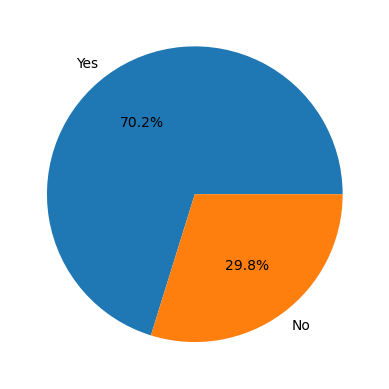

In [10]:
plt.pie(data["loan_approved"].value_counts(),labels = ["Yes","No"],autopct="%1.1f%%")


<Axes: xlabel='gender', ylabel='count'>

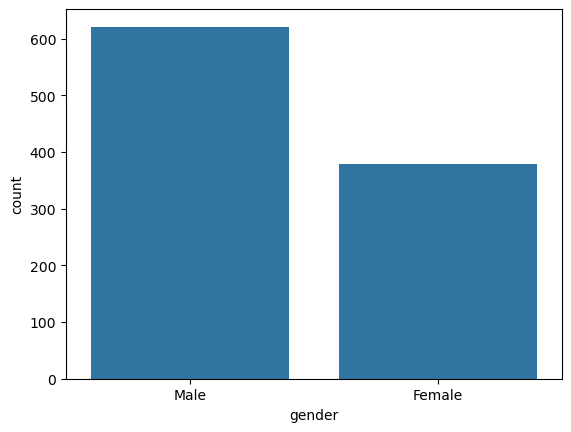

In [11]:
gender_count = data["gender"].value_counts()
sns.barplot(gender_count)

<Axes: xlabel='education_level', ylabel='count'>

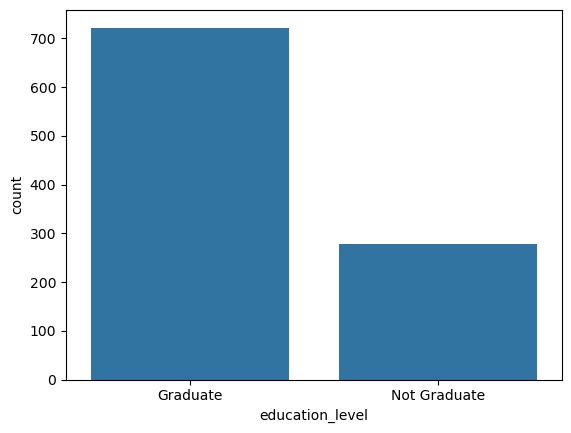

In [12]:
edu_lvl = data["education_level"].value_counts()
sns.barplot(edu_lvl)

([<matplotlib.patches.Wedge at 0x26dc3fc9ca0>,
 [Text(-0.6521425632196803, 0.8858386293435534, 'No'),
  Text(0.6521426461578755, -0.8858385682855563, 'Yes')],
 [Text(-0.35571412539255287, 0.4831847069146654, '70.2%'),
  Text(0.3557141706315684, -0.4831846736103034, '29.8%')])

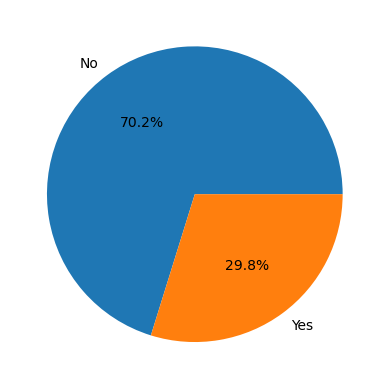

In [16]:
classes_count = data["loan_approved"].value_counts()
plt.pie(classes_count,labels=["No","Yes"],autopct="%1.1f%%")

<Axes: xlabel='gender', ylabel='count'>

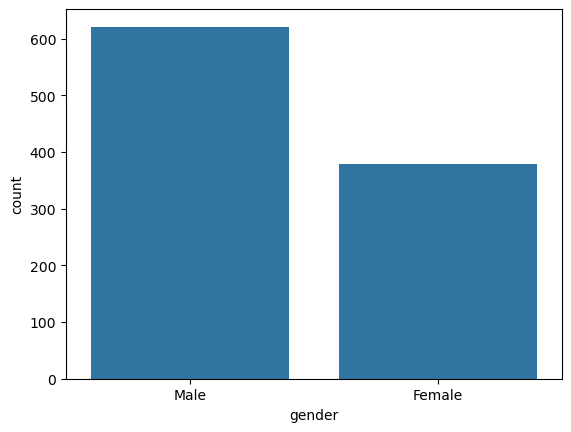

In [18]:
gender_count
sns.barplot(gender_count)

<Axes: xlabel='applicant_income', ylabel='Count'>

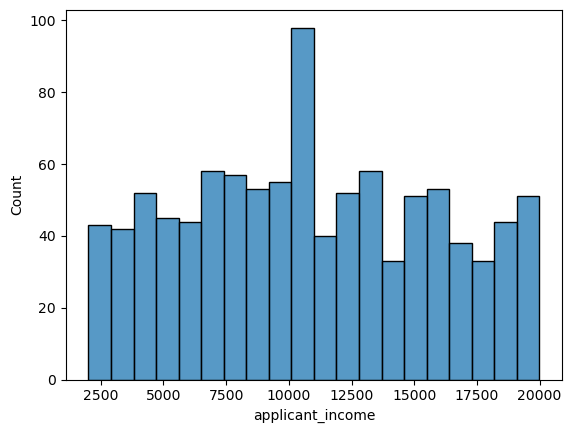

In [19]:
sns.histplot(data=data,
    x="applicant_income",
    bins=20
)

<Axes: xlabel='coapplicant_income', ylabel='Count'>

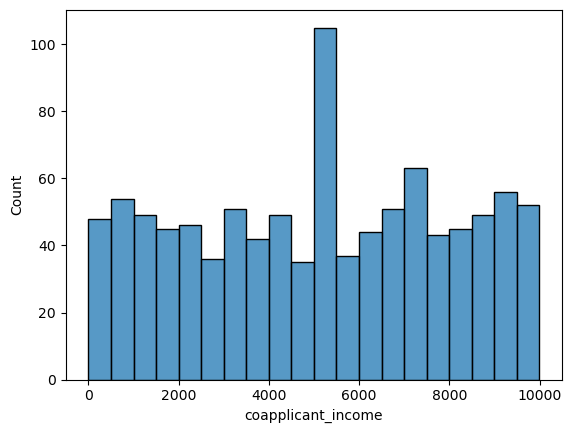

In [20]:
sns.histplot(data=data,
    x="coapplicant_income",
    bins=20
)

<Axes: xlabel='loan_approved', ylabel='applicant_income'>

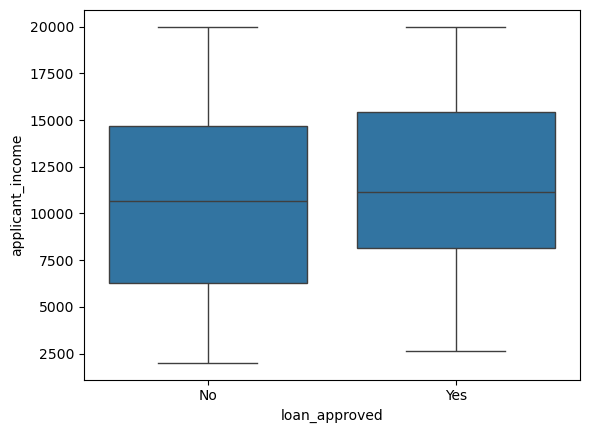

In [22]:
sns.boxplot(
    data=data,
    x="loan_approved",
    y="applicant_income"
)

#Usually, rejected loans had lower income than accepted

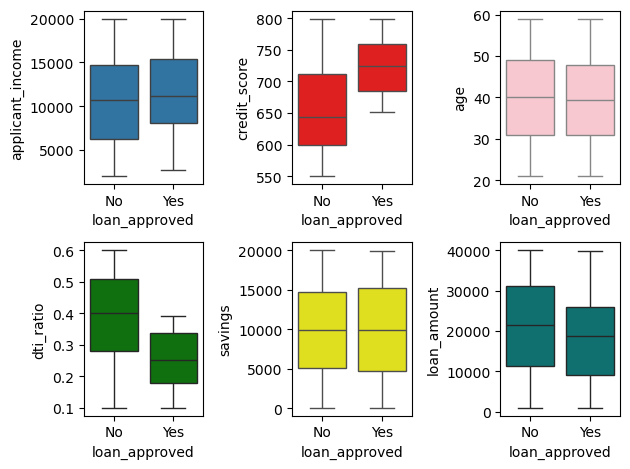

In [32]:
fig,axes = plt.subplots(2,3)
sns.boxplot(
    data = data,
    x="loan_approved",
    y = "applicant_income",
    ax=axes[0,0]
)
sns.boxplot(
    data = data,
    x="loan_approved",
    y = "credit_score",
    ax=axes[0,1],
    color="red"
)
sns.boxplot(
    data=data,
    x="loan_approved",
    y="age",
    ax=axes[0,2],
    color="pink"
)
sns.boxplot(
    data = data,
    x="loan_approved",
    y = "dti_ratio",
    ax=axes[1,0],
    color="green"
)
sns.boxplot(
    data = data,
    x="loan_approved",
    y = "savings",
    ax=axes[1,1],
    color="yellow"
)
sns.boxplot(
    data=data,
    x="loan_approved",
    y="loan_amount",
    ax=axes[1,2],
    color="teal"
)
plt.tight_layout()